<a href="https://colab.research.google.com/github/Ashishsantoshsharma/Sales-Analytics-Project/blob/main/tata_data_analytics_GenAI_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("/content/Delinquency_prediction_dataset.xlsx")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
df.head(5)

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [ ]:
df.describe().round()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.0,461.0,498.0,500.0,500.0,500.0,471.0,500.0,500.0
mean,46.0,108380.0,578.0,0.0,3.0,0.0,48654.0,0.0,10.0
std,16.0,53663.0,169.0,0.0,2.0,0.0,29396.0,0.0,6.0
min,18.0,15404.0,301.0,0.0,0.0,0.0,612.0,0.0,0.0
25%,33.0,62295.0,418.0,0.0,1.0,0.0,23716.0,0.0,5.0
50%,46.0,107658.0,586.0,0.0,3.0,0.0,45776.0,0.0,10.0
75%,59.0,155734.0,727.0,1.0,5.0,0.0,75546.0,0.0,15.0
max,74.0,199943.0,847.0,1.0,6.0,1.0,99620.0,1.0,19.0


In [ ]:
df.columns

Index(['Customer_ID', 'Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure',
       'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3',
       'Month_4', 'Month_5', 'Month_6'],
      dtype='object')

In [ ]:
df.shape

(500, 19)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Income,0
Credit_Score,0
Credit_Utilization,0
Missed_Payments,0
Delinquent_Account,0
Loan_Balance,0
Debt_to_Income_Ratio,0
Employment_Status,0


In [ ]:
# Fill numeric columns
df["Income"].fillna(df["Income"].median(), inplace=True)
df["Loan_Balance"].fillna(df["Loan_Balance"].median(), inplace=True)
df["Credit_Score"].fillna(df["Credit_Score"].mean(), inplace=True)

/tmp/ipykernel_1875/3294432455.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Income"].fillna(df["Income"].median(), inplace=True)
/tmp/ipykernel_1875/3294432455.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [ ]:
payment_cols = ["Month_1", "Month_2", "Month_3", "Month_4", "Month_5", "Month_6"]

mapping = {"On-time": 0, "Late": 1, "Missed": 2}

for col in payment_cols:
    df[col] = df[col].map(mapping)

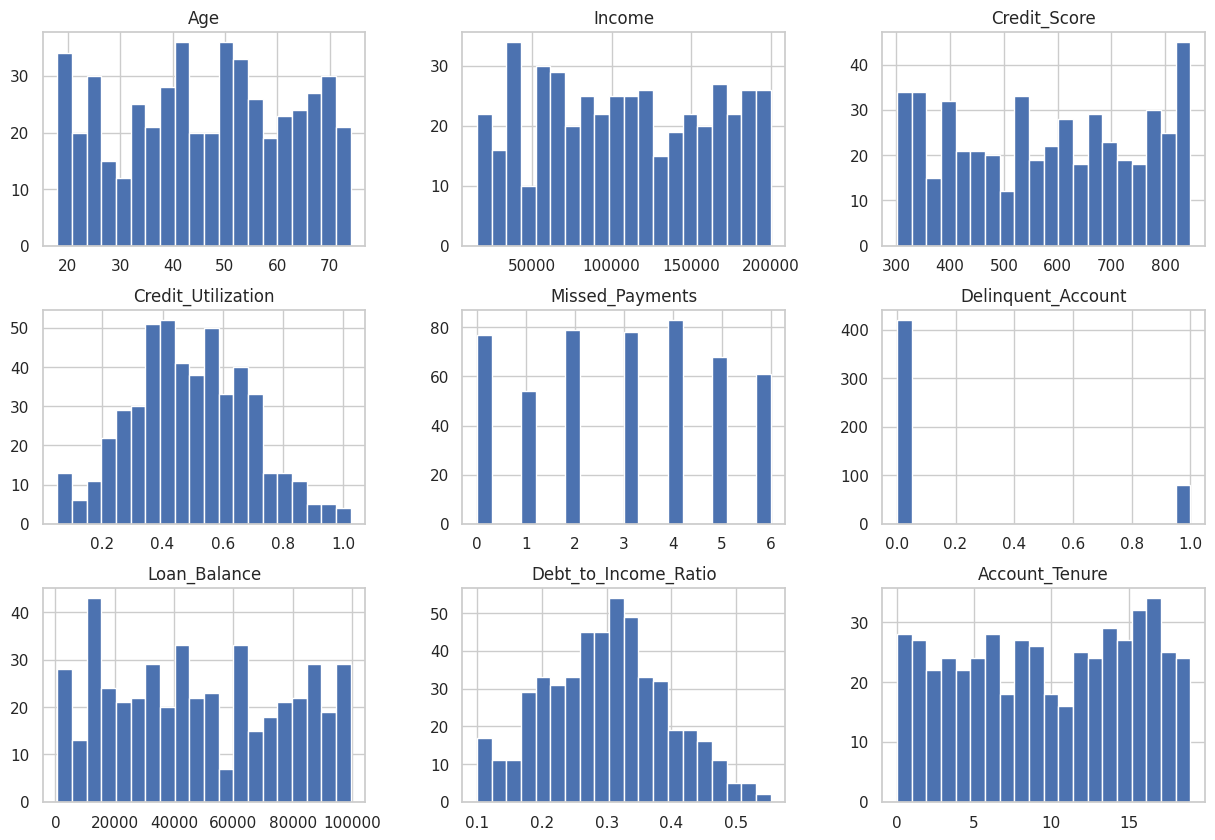

In [ ]:
df.hist(bins=20, figsize=(15,10))
plt.show()

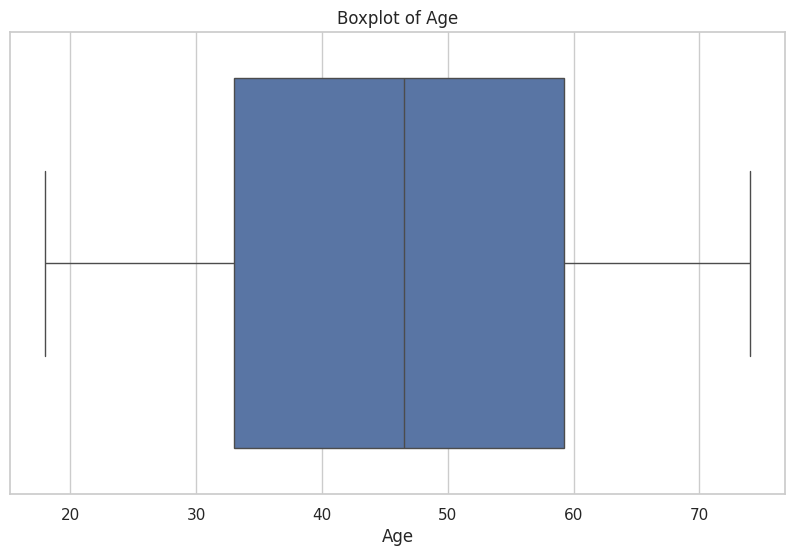

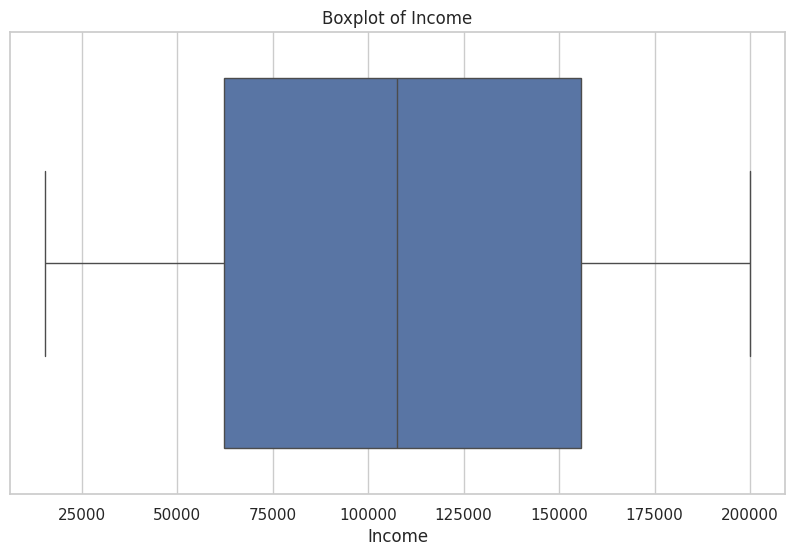

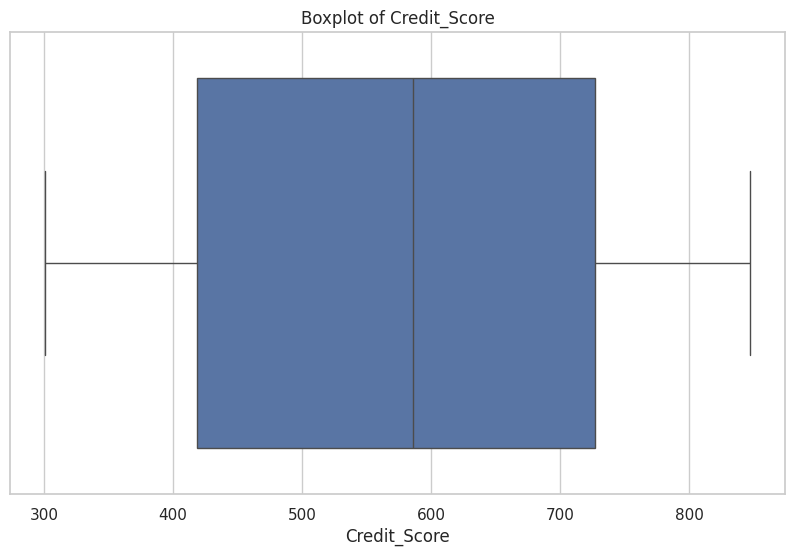

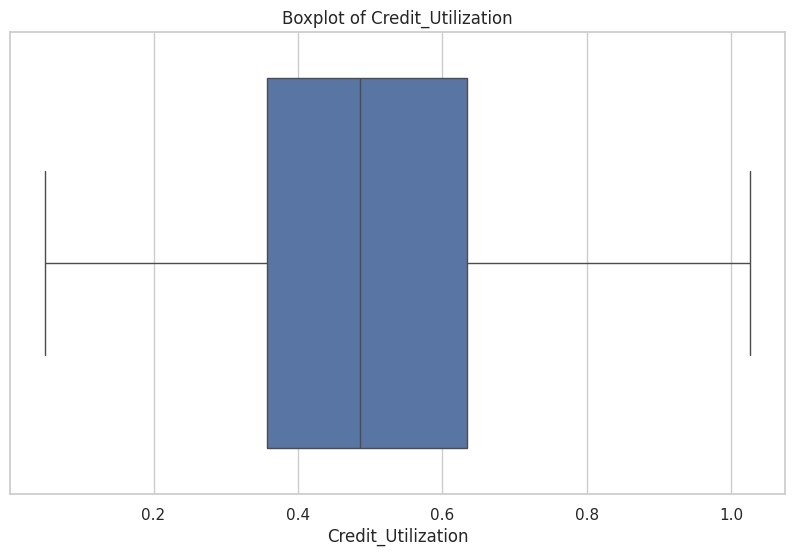

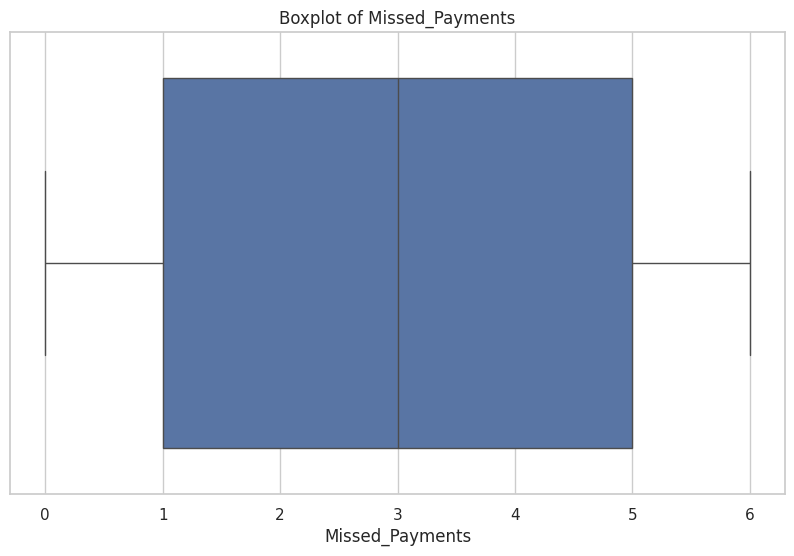

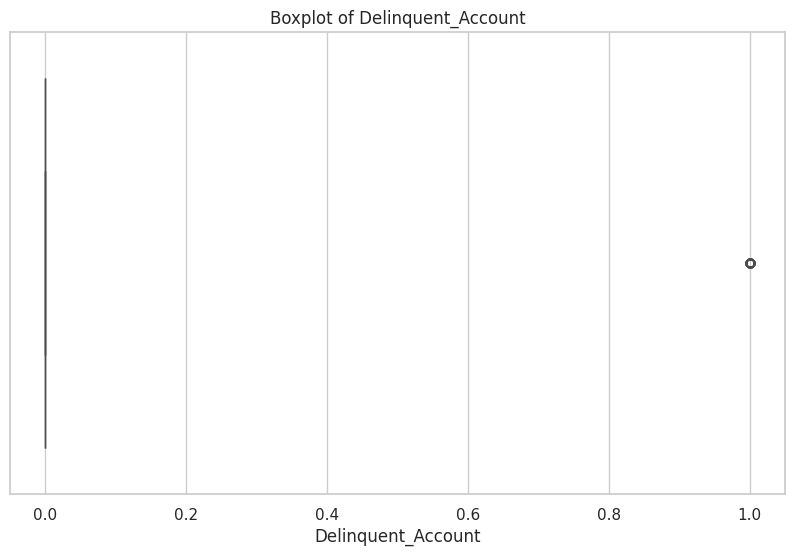

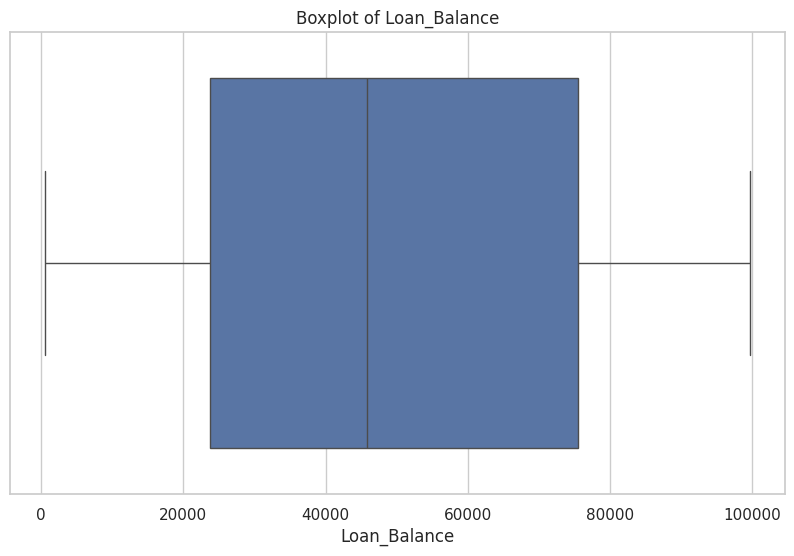

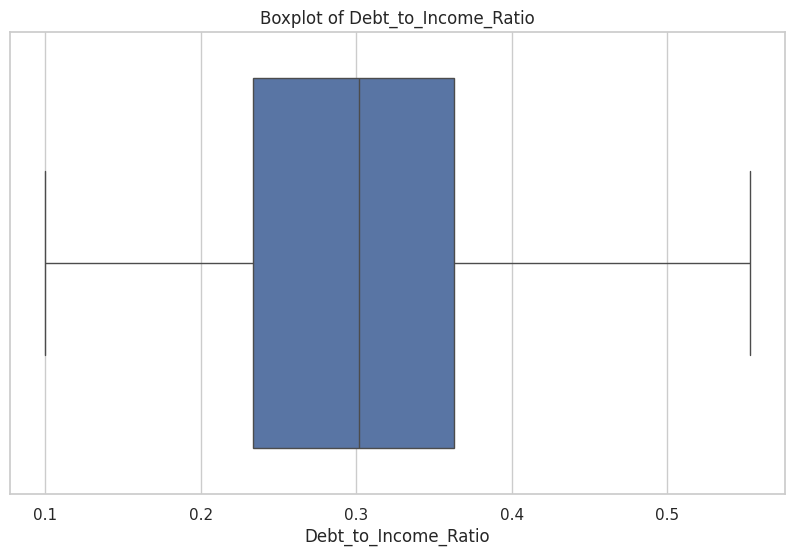

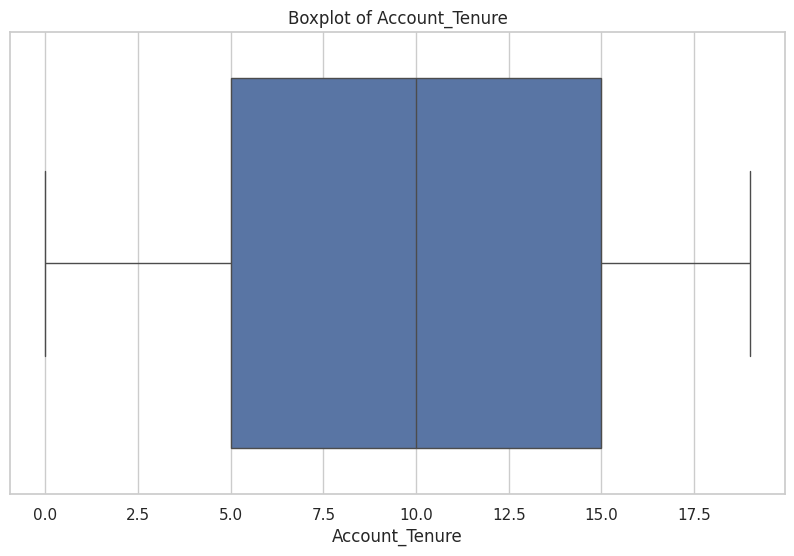

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

for col in num_cols:
    detect_outliers(col)

Age: 0 outliers
Income: 0 outliers
Credit_Score: 0 outliers
Credit_Utilization: 0 outliers
Missed_Payments: 0 outliers
Delinquent_Account: 80 outliers
Loan_Balance: 0 outliers
Debt_to_Income_Ratio: 0 outliers
Account_Tenure: 0 outliers


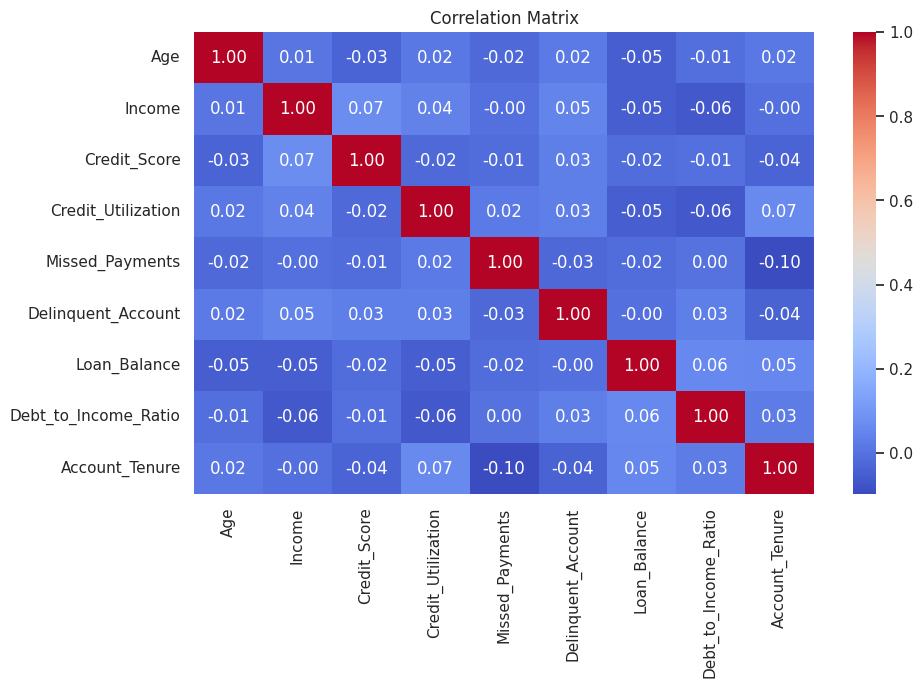

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

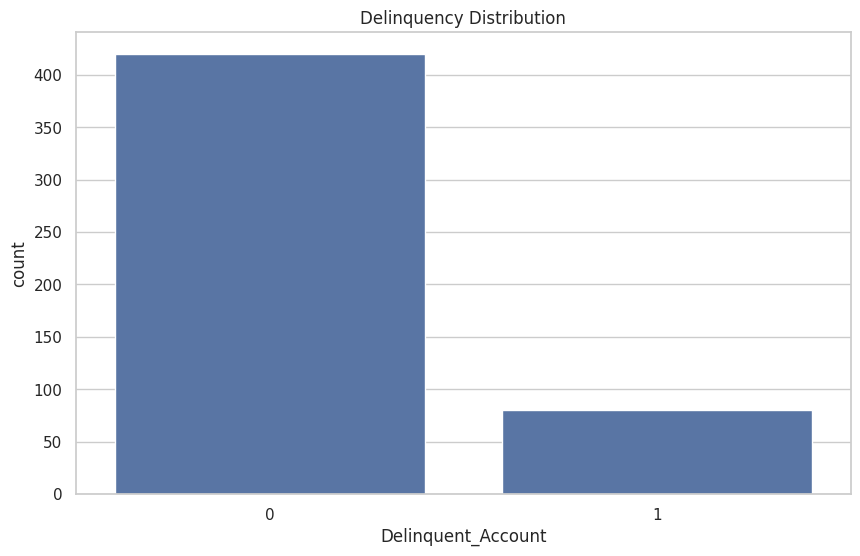

In [ ]:
sns.countplot(x="Delinquent_Account", data=df)
plt.title("Delinquency Distribution")
plt.show()

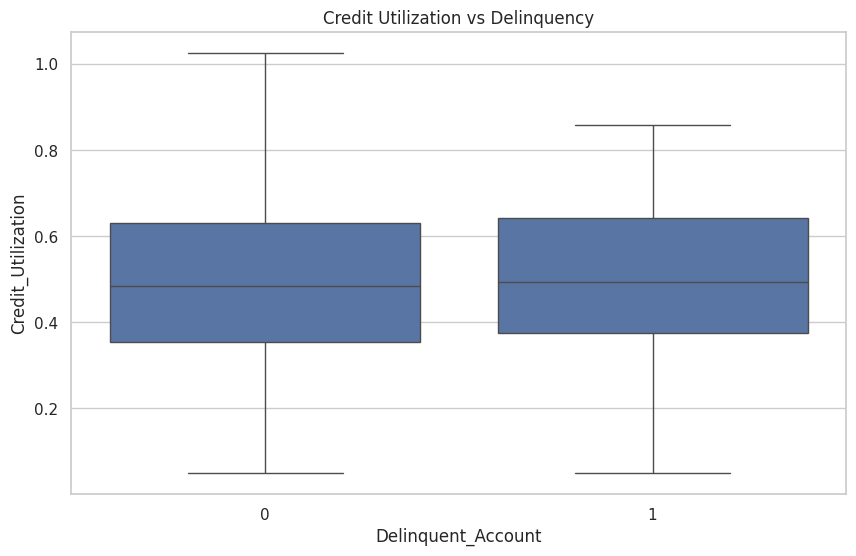

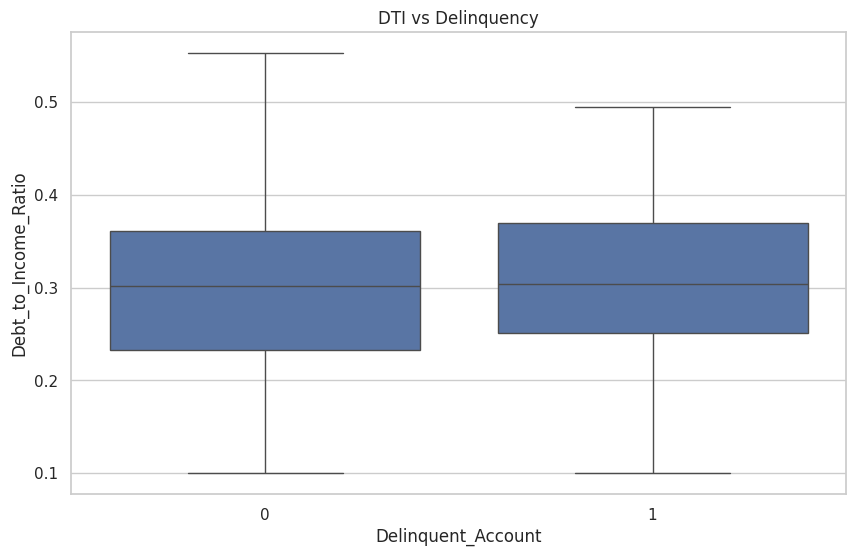

In [ ]:
sns.boxplot(x="Delinquent_Account", y="Credit_Utilization", data=df)
plt.title("Credit Utilization vs Delinquency")
plt.show()

sns.boxplot(x="Delinquent_Account", y="Debt_to_Income_Ratio", data=df)
plt.title("DTI vs Delinquency")
plt.show()

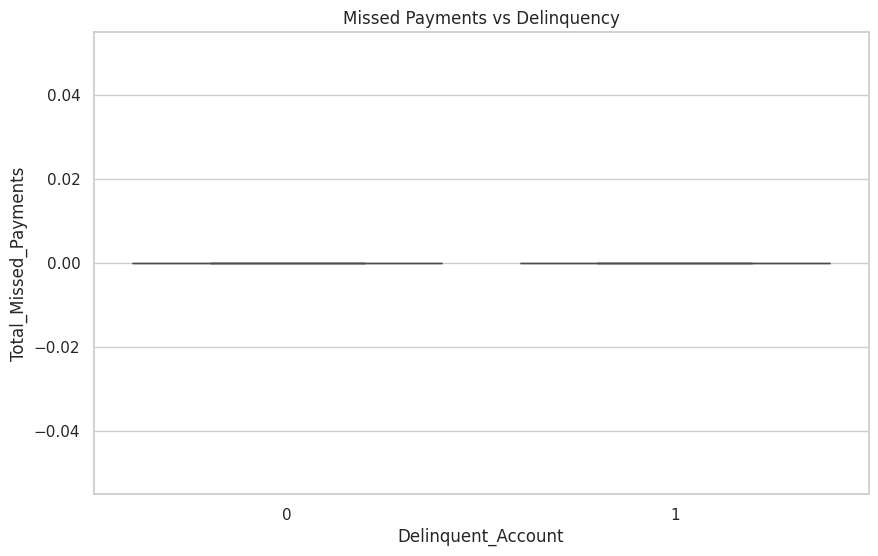

In [ ]:
df["Total_Late_Payments"] = (df[payment_cols] == 1).sum(axis=1)
df["Total_Missed_Payments"] = (df[payment_cols] == 2).sum(axis=1)

sns.boxplot(x="Delinquent_Account", y="Total_Missed_Payments", data=df)
plt.title("Missed Payments vs Delinquency")
plt.show()

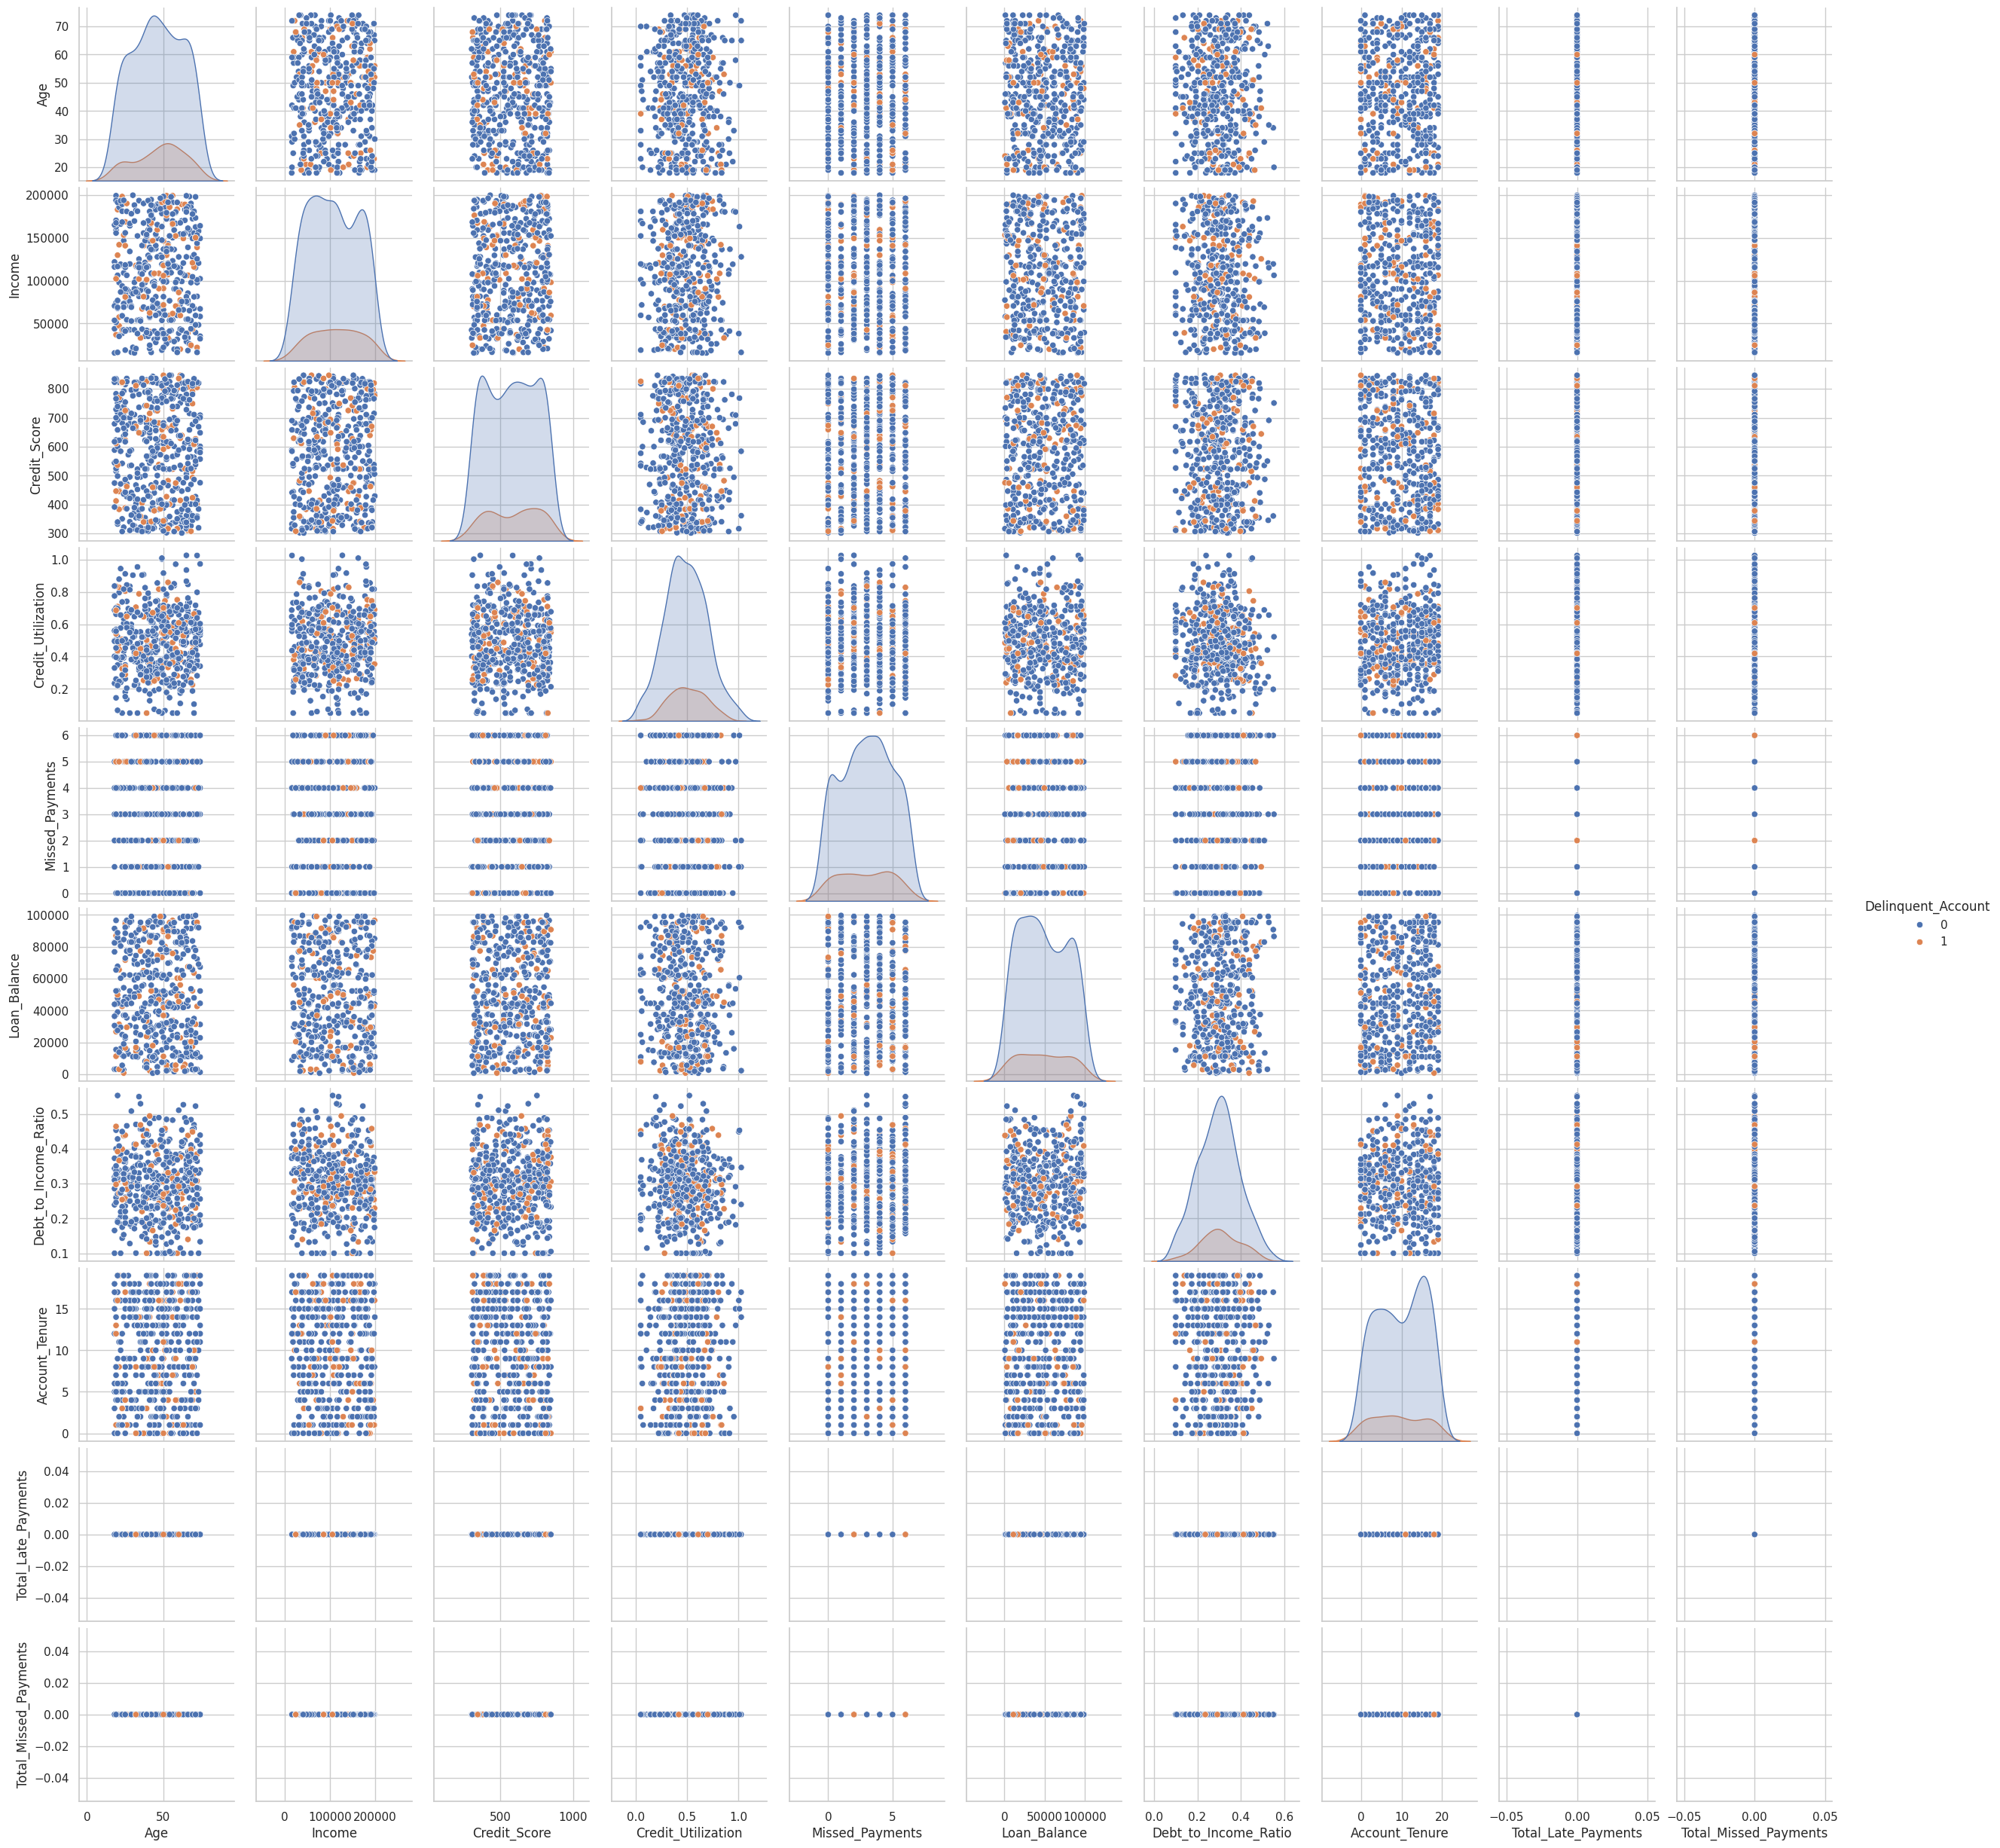

In [ ]:
sns.pairplot(df, hue="Delinquent_Account")
plt.show()

In [ ]:
print("Average Credit Utilization by Delinquency:")
print(df.groupby("Delinquent_Account")["Credit_Utilization"].mean())

print("\nAverage DTI by Delinquency:")
print(df.groupby("Delinquent_Account")["Debt_to_Income_Ratio"].mean())

Average Credit Utilization by Delinquency:
Delinquent_Account
0    0.488505
1    0.506887
Name: Credit_Utilization, dtype: float64

Average DTI by Delinquency:
Delinquent_Account
0    0.297445
1    0.306301
Name: Debt_to_Income_Ratio, dtype: float64


In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)